### Main Training Notebook

In [3]:
# Install dependencies
# %pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [19]:
import subprocess
import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [20]:
OUTPUT_DIR = "./saved_models"

In [21]:
def convert_and_import(notebook_name, notebook_dir="."):
    nb_path = os.path.join(notebook_dir, f"{notebook_name}.ipynb")
    if not os.path.exists(nb_path):
        raise FileNotFoundError(f"Not found: {nb_path}")
    subprocess.run(
        [sys.executable, "-m", "nbconvert", "--to", "script",
         "--output", notebook_name, nb_path],
        capture_output=True, check=True
    )
    if notebook_dir not in sys.path:
        sys.path.insert(0, notebook_dir)
    if notebook_name in sys.modules:
        mod = importlib.reload(sys.modules[notebook_name])
    else:
        mod = importlib.import_module(notebook_name)
    print(f"Done with {notebook_name}")
    return mod

In [22]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))

ALL_NOTEBOOKS = [
    "model_isolation_forest"
]

print("Importing notebooks...")
mods = {n: convert_and_import(n, NOTEBOOK_DIR) for n in ALL_NOTEBOOKS}

Importing notebooks...
Done with model_isolation_forest


In [23]:
if_mod   = mods["model_isolation_forest"]

In [24]:
# DATA LOADING

USE_DEMO_DATA = True

if USE_DEMO_DATA:
    X_raw, y_raw_int = make_classification(
        n_samples=12_000, n_features=84, n_informative=40,
        n_classes=8, n_clusters_per_class=1, random_state=42
    )
    ATTACK_CLASSES = ["Benign", "DDoS", "DoS", "Recon",
                      "Web-based", "BruteForce", "Spoofing", "Mirai"]
    y_raw = np.array([ATTACK_CLASSES[i] for i in y_raw_int])
    X_raw = pd.DataFrame(X_raw, columns=[f"feature_{i}" for i in range(84)])

else:
    # PROCESSED DATA SHOULD BE HERE
    pass

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42
)

NORMAL_LABEL = "Benign"

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
vals, counts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  {v:15s}: {c:6,}")

Train : (8670, 84)  |  Val : (1530, 84)  |  Test : (1800, 84)
  Benign         :  1,080
  BruteForce     :  1,087
  DDoS           :  1,081
  DoS            :  1,081
  Mirai          :  1,082
  Recon          :  1,086
  Spoofing       :  1,086
  Web-based      :  1,087


Isolation Forest Anomaly Detector
Training on 1,080 benign samples (excluded 7,590 attack samples).
Isolation Forest fitted.
Threshold tuned: 0.08917  (val F1=0.9341)

Accuracy: 0.8771 | F1 (Attack): 0.9341 | ROC-AUC: 0.6107
              precision    recall  f1-score   support

      Benign       0.56      0.05      0.09       190
      Attack       0.88      0.99      0.93      1340

    accuracy                           0.88      1530
   macro avg       0.72      0.52      0.51      1530
weighted avg       0.84      0.88      0.83      1530

Saved > ./saved_models/isolation_forest.joblib


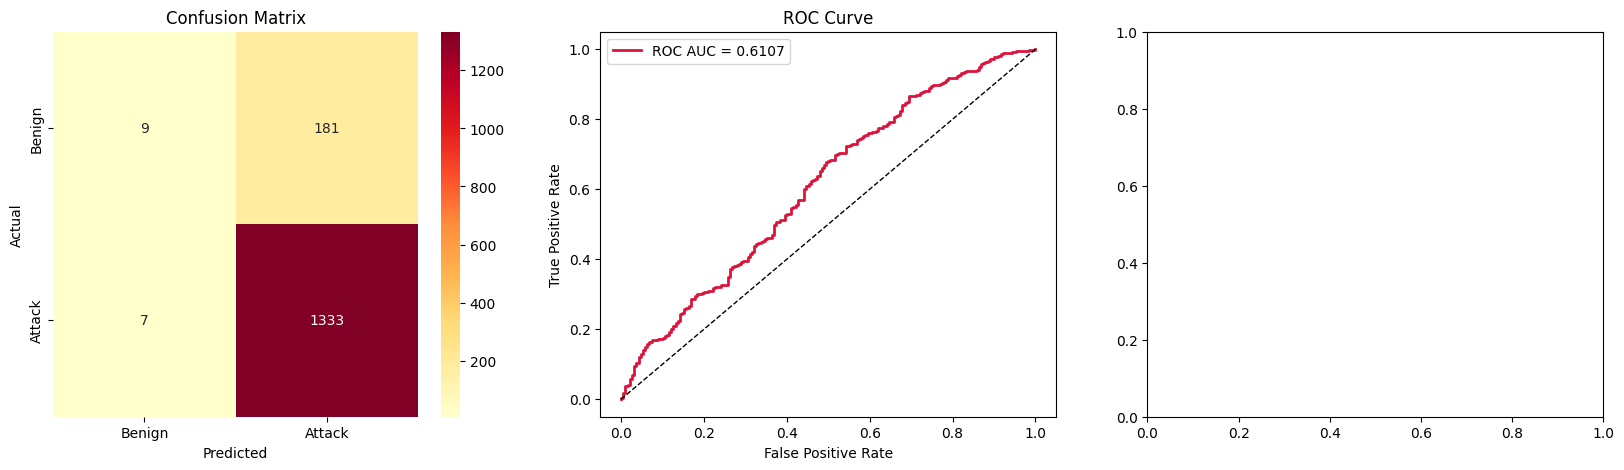

In [25]:
print("=" * 60)
print("Isolation Forest Anomaly Detector")
print("=" * 60)

model, threshold, metrics = if_mod.train(
    X_train, y_train,
    X_val, y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs= {
        "n_estimators":  200,
        "max_samples":   256,
        "contamination": "auto",
        "max_features":  1.0,
    },
    tune_threshold=True,
    save_path=os.path.join(OUTPUT_DIR, "isolation_forest.joblib")
)